# Phase 1: Data Ingestion & Preprocessing
## 1. Import Libraries

In [25]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Load and Merge Data

In [26]:
dataset_path = '../datasets'
all_files = glob.glob(os.path.join(dataset_path, '*.csv'))
print(f"Found {len(all_files)} CSV files.")

df_list = []
for f in all_files:
    print(f"Loading: {os.path.basename(f)}")
    df_list.append(pd.read_csv(f))

df = pd.concat(df_list, ignore_index=True)
print(f"Total shape: {df.shape}")

Found 8 CSV files.
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Total shape: (2830743, 79)


## 3. Data Cleaning and Memory Optimization

In [27]:
# Strip whitespaces from column names
df.columns = df.columns.str.strip()

# Handle inf and NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].fillna(df[col].median(), inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop zero-variance features
nunique = df.nunique()
cols_to_drop = nunique[nunique == 1].index
df.drop(columns=cols_to_drop, inplace=True)
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (2522362, 71)


In [28]:
# Memory Optimization (Downcasting)
def downcast_dtypes(df):
    float_cols = [c for c in df if df[c].dtype == "float64"]
    int_cols = [c for c in df if df[c].dtype in ["int64", "int32"]]
    df[float_cols] = df[float_cols].astype(np.float32)
    df[int_cols] = df[int_cols].astype(np.uint32)
    return df

df = downcast_dtypes(df)
df.info()

<class 'pandas.DataFrame'>
Index: 2522362 entries, 0 to 2830742
Data columns (total 71 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             uint32 
 1   Flow Duration                uint32 
 2   Total Fwd Packets            uint32 
 3   Total Backward Packets       uint32 
 4   Total Length of Fwd Packets  uint32 
 5   Total Length of Bwd Packets  uint32 
 6   Fwd Packet Length Max        uint32 
 7   Fwd Packet Length Min        uint32 
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        uint32 
 11  Bwd Packet Length Min        uint32 
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flow IAT Max                 uint32 
 19  Flow IAT Min    

## 4. Exploratory Data Analysis (EDA)

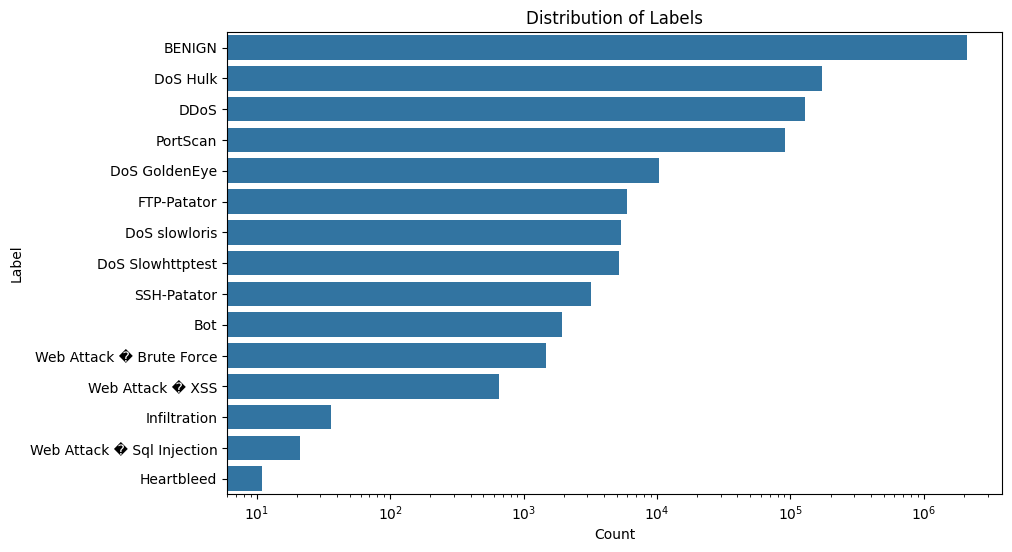

In [29]:
# Label Distribution
plt.figure(figsize=(10,6))
sns.countplot(y=df['Label'], order=df['Label'].value_counts().index)
plt.title('Distribution of Labels')
plt.xlabel('Count')
plt.ylabel('Label')
plt.xscale('log') # Log scale due to severe imbalance
plt.show()

## 5. Correlation Heatmap
To understand the relationship between features and understand the underlying data structure.

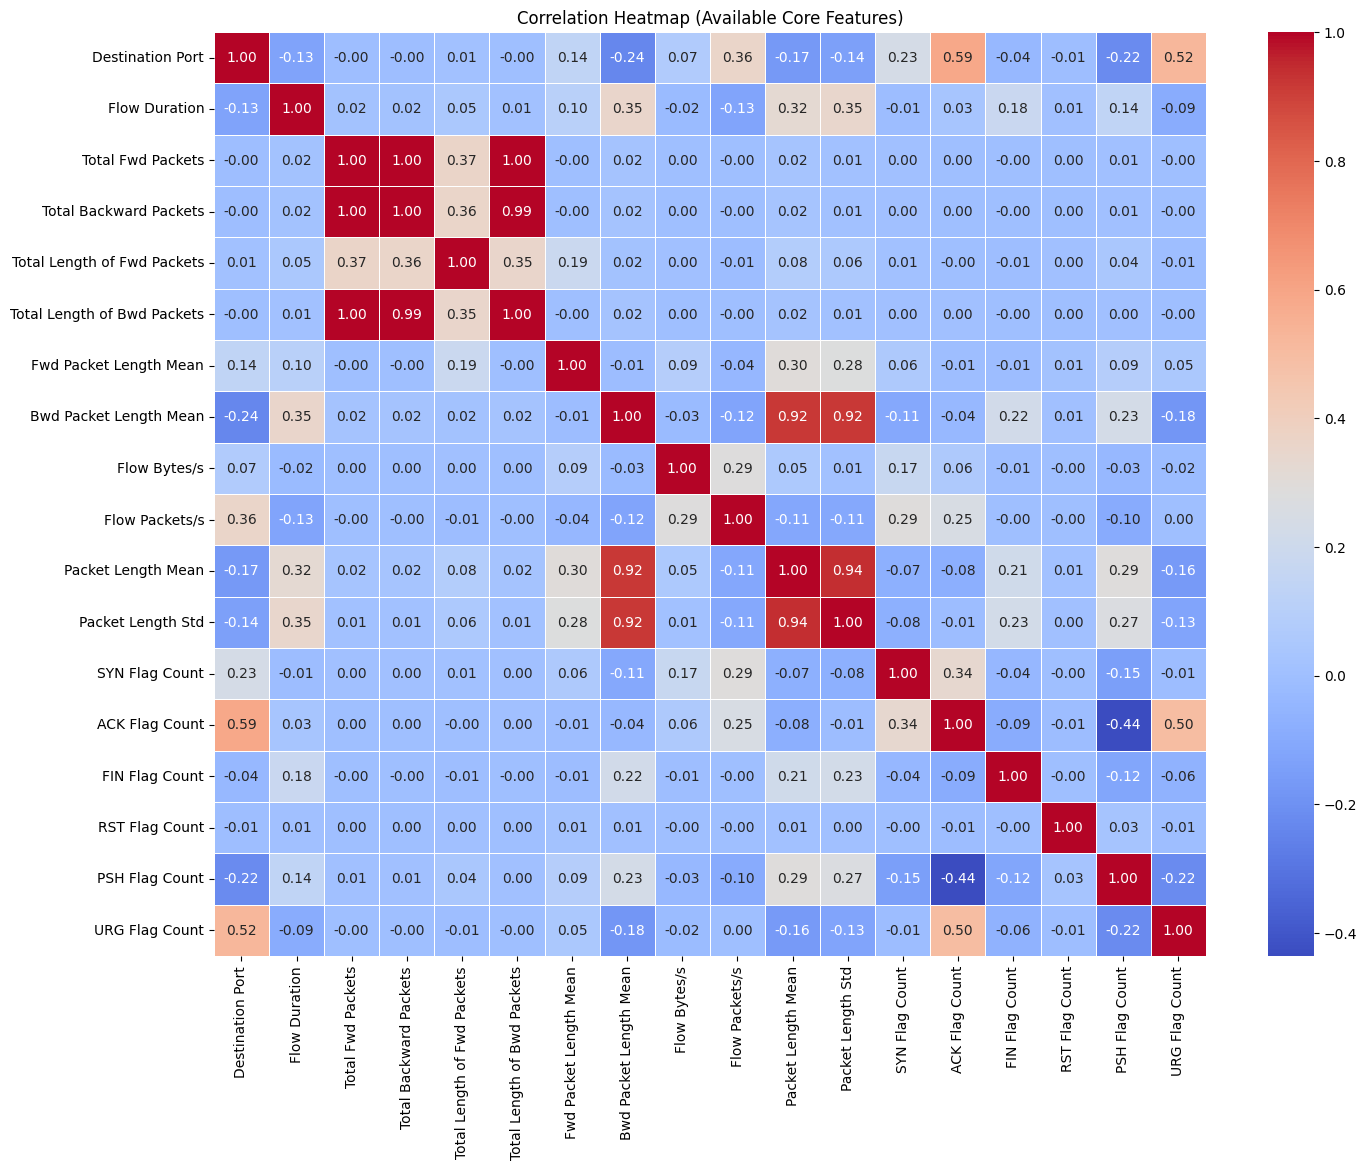

In [30]:
selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 'Packet Length Std', 
    'SYN Flag Count', 'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count', 
    'PSH Flag Count', 'URG Flag Count'
]

available_cols = [col for col in selected_features if col in df.columns]

if len(available_cols) < len(selected_features):
    missing = set(selected_features) - set(available_cols)
    print(f"Lưu ý: Đã bỏ qua các cột không tồn tại: {missing}")

plt.figure(figsize=(16, 12))
sns.heatmap(df[available_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Available Core Features)')
plt.show()

In [31]:
# Save the cleaned dataframe to parquet or csv for next steps
os.makedirs('../datasets', exist_ok=True)
df.to_parquet('../datasets/cleaned_data.parquet', index=False)
print("Cleaned data saved to ../datasets/cleaned_data.parquet")

Cleaned data saved to ../datasets/cleaned_data.parquet
